#  Food Delivery Customer Churn Prediction

**Objective**

The objective of this project is to predict which customers are likely to stop ordering food and identify key factors influencing churn. This helps businesses design targeted retention strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Dataset**

In [ ]:
df = pd.read_csv("/content/onlinefoods.csv")
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


**Data Overview**

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


**Creating Target Variable (Churn)**

In [ ]:
df["Churn"] = (df["Output"] == "No").astype(int)

**Data Cleaning**

In [ ]:
df.dropna(inplace=True)

**Exploratory Data Analysis (EDA)**

Churn Distribution

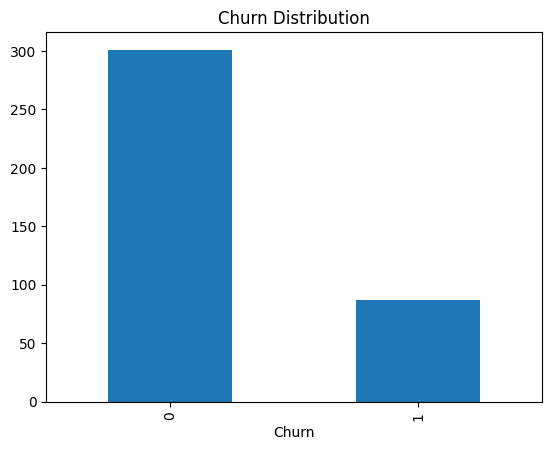

In [ ]:
df["Churn"].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

Numerical Distribution

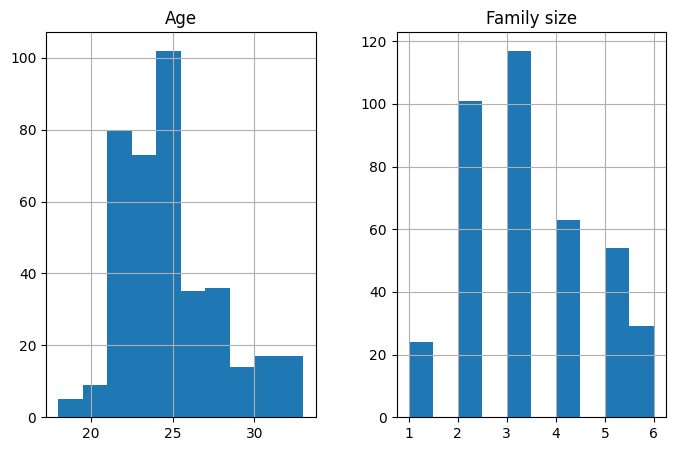

In [ ]:
df[["Age","Family size"]].hist(figsize=(8,5))
plt.show()

Categorical Analysis

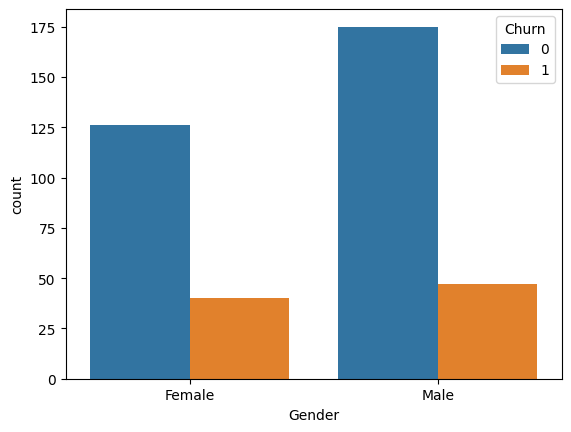

In [ ]:
sns.countplot(x="Gender", hue="Churn", data=df)
plt.show()

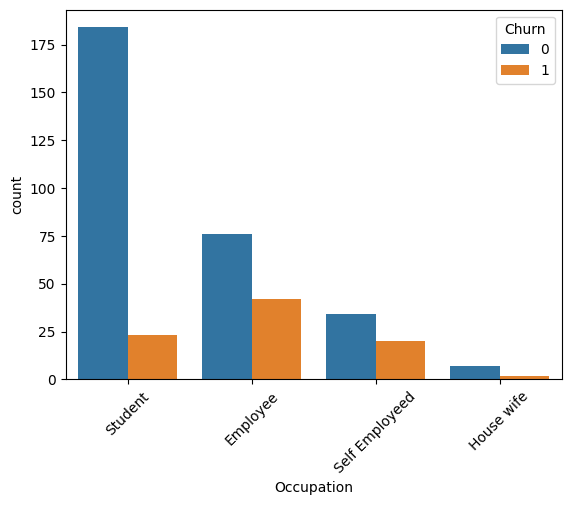

In [ ]:
sns.countplot(x="Occupation", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

Relationship Analysis

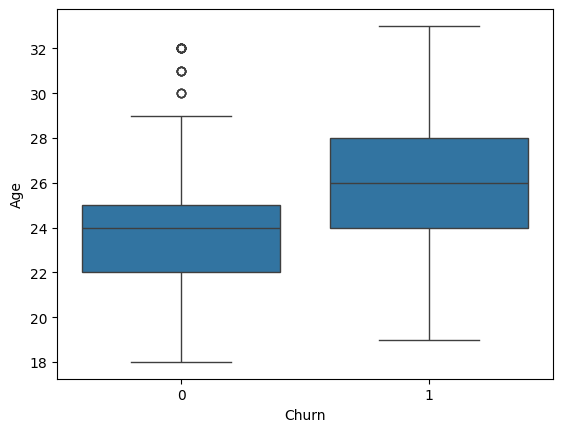

In [ ]:
sns.boxplot(x="Churn", y="Age", data=df)
plt.show()

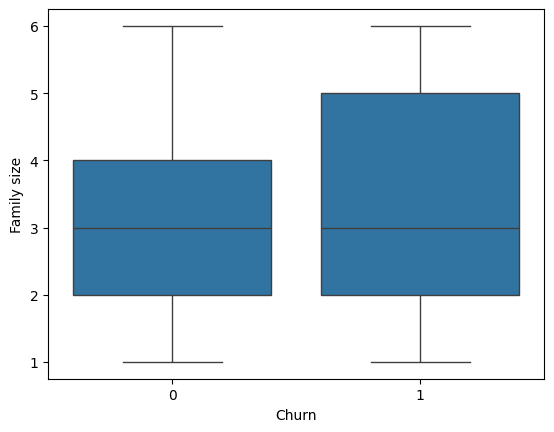

In [ ]:
sns.boxplot(x="Churn", y="Family size", data=df)
plt.show()

Correlation

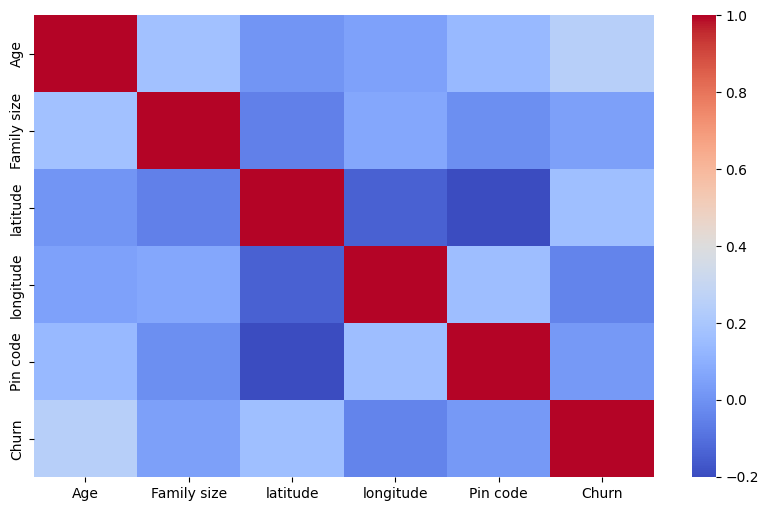

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

**EDA Insights**

- Younger users show higher churn tendency  
- Certain occupations have higher churn rates  
- Family size influences ordering behavior  
- Moderate class imbalance observed  

**Feature Engineering**

In [ ]:
df["Engagement"] = df["Family size"] * df["Age"]

In [ ]:
df["Age_Group"] = pd.cut(df["Age"], bins=[18,25,35,50,70], labels=["Young","Adult","Mid","Senior"])

In [ ]:
df["High_Value"] = (df["Family size"] > df["Family size"].median()).astype(int)

In [ ]:
df["Risk_Score"] = df["Age"] / (df["Family size"] + 1)

**Encoding Categorical Variables**

In [ ]:
df = pd.get_dummies(df, drop_first=True)

**Feature Selection**

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

**Class Imbalance**

In [ ]:
y.value_counts()

,count
Churn,
0,301
1,87


**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic Regression (Baseline Model)**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[66  0]
 [ 0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        12

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



**Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 1.0


**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        12

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



**Confusion Matrix**

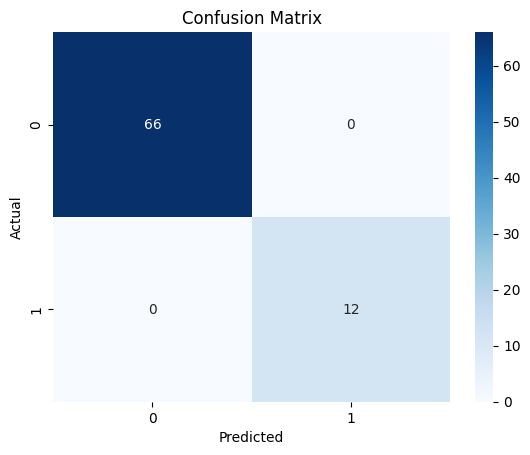

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Churn Probability Prediction**

In [ ]:
probs = rf.predict_proba(X_test)[:,1]

**Probability-Based Insight**

Instead of only predicting churn, the model estimates churn probability, allowing businesses to identify high-risk customers and take preventive action.

**Feature Importance**

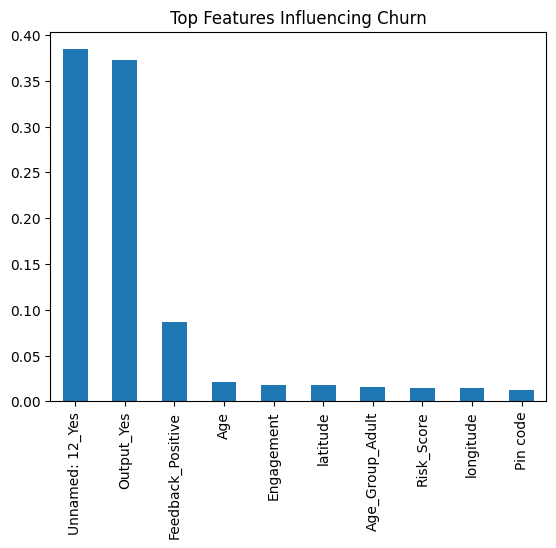

In [ ]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Features Influencing Churn")
plt.show()

**Feature Importance Insights**

- Engagement and usage patterns strongly influence churn  
- Demographic features also impact behavior  
- Low engagement is a key indicator of churn  

**Feature Importance**

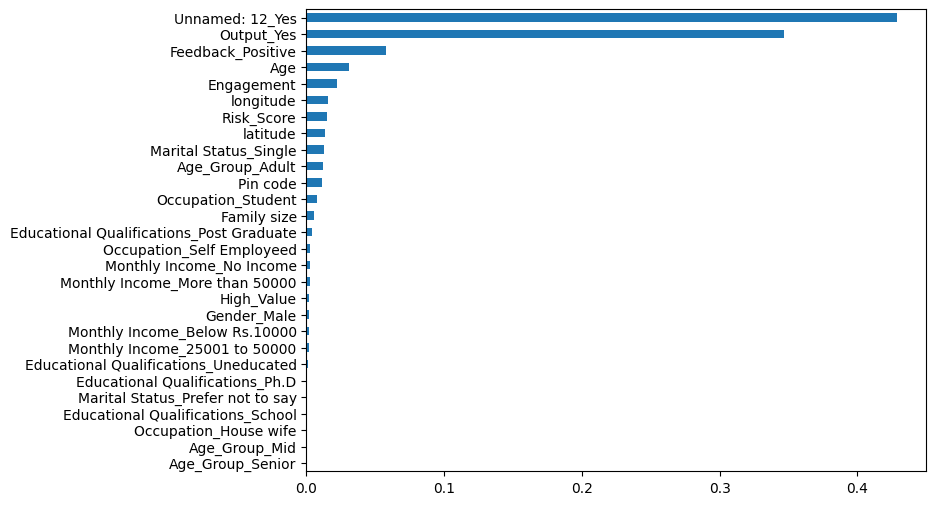

In [ ]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.show()

**Business Insights**

- Users with low engagement are more likely to churn  
- Age and family size influence ordering behavior  
- High-value users require retention strategies  

**Business Recommendations**

- Target high-risk users with personalized offers  
- Improve engagement for low-activity users  
- Provide loyalty rewards to retain valuable customers  

**Conclusion**

This project demonstrates how machine learning can be used to predict customer churn and generate actionable business insights to improve retention and revenue.

In [ ]:
import joblib

joblib.dump(rf, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import joblib

joblib.dump(X.columns, "features.pkl")

['features.pkl']